# Einflussanalyse der Fahrzeugpreise

## Ziel der Analyse

Ziel dieser Analyse ist die Untersuchung der wichtigsten Einflussfaktoren auf den Fahrzeugpreis.

Dabei wird analysiert, welche Merkmale den stärksten Einfluss auf die Preisgestaltung von Fahrzeugen besitzen.

Die Ergebnisse sollen wichtige Erkenntnisse für die spätere Modellierung und Preisvorhersage liefern.

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("default")

In [13]:
df = pd.read_csv("data/processed/cleaned_data.csv")

print("Datensatzgröße:", df.shape)

df.head()

Datensatzgröße: (1200, 13)


,Datum,Marke,Modell,Preis_Euro,Verkaufszahl,Kraftstoff,Getriebe,Hubraum_L,Bundesland,Kundenzufriedenheit,Jahr,Monat,Wochentag
0,2024-01-01,Mercedes-Benz,C-Klasse,66835,2,Elektro,Automatik,0.0,Berlin,4.7,2024,1,Monday
1,2024-01-01,Mercedes-Benz,E-Klasse,93803,2,Benzin,Manuell,1.2,Nrw,3.2,2024,1,Monday
2,2024-01-07,Volkswagen,Passat,45929,6,Hybrid,Manuell,2.0,Baden-Württemberg,3.2,2024,1,Sunday
3,2024-01-07,Mercedes-Benz,C-Klasse,76943,3,Diesel,Automatik,4.0,Berlin,3.4,2024,1,Sunday
4,2024-01-08,Bmw,5Er,107912,1,Elektro,Automatik,0.0,Berlin,3.2,2024,1,Monday


In [14]:
print("Spalten im Datensatz:")
print(df.columns.tolist())

print("\nFehlende Werte pro Spalte:")
print(df.isnull().sum())

Spalten im Datensatz:
['Datum', 'Marke', 'Modell', 'Preis_Euro', 'Verkaufszahl', 'Kraftstoff', 'Getriebe', 'Hubraum_L', 'Bundesland', 'Kundenzufriedenheit', 'Jahr', 'Monat', 'Wochentag']

Fehlende Werte pro Spalte:
Datum                  0
Marke                  0
Modell                 0
Preis_Euro             0
Verkaufszahl           0
Kraftstoff             0
Getriebe               0
Hubraum_L              0
Bundesland             0
Kundenzufriedenheit    0
Jahr                   0
Monat                  0
Wochentag              0
dtype: int64


In [15]:
marke_preis = (
    df.groupby("Marke")["Preis_Euro"]
    .mean()
    .sort_values(ascending=False)
)

marke_preis

Marke
Mercedes-Benz    83255.546256
Bmw              77082.673820
Audi             71455.683333
Volkswagen       42521.003922
Opel             31398.665306
Name: Preis_Euro, dtype: float64

Marke hat einen sehr starken Einfluss auf den Fahrzeugpreis.

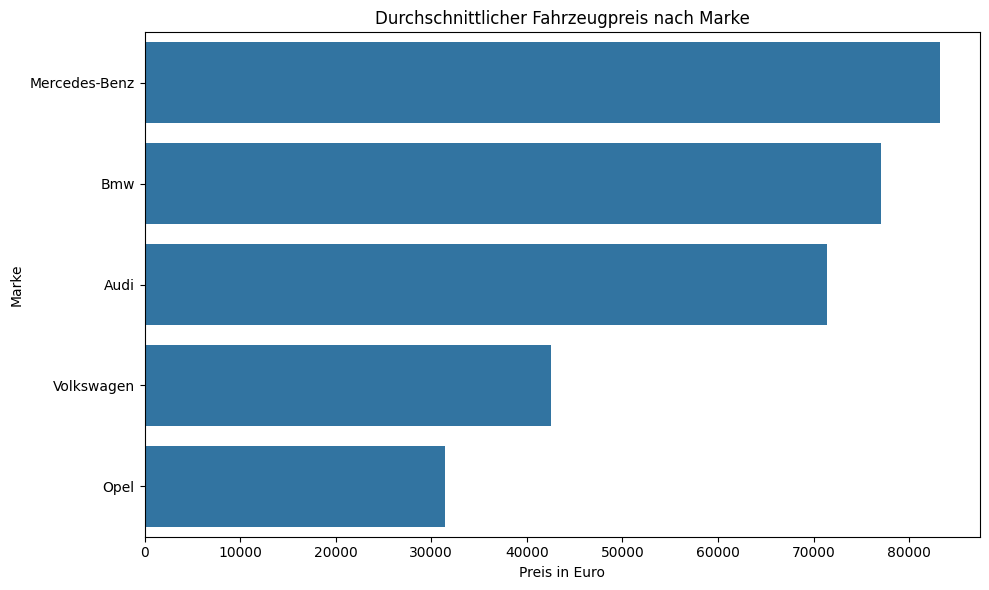

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=marke_preis.values,
    y=marke_preis.index
)

plt.title("Durchschnittlicher Fahrzeugpreis nach Marke")
plt.xlabel("Preis in Euro")
plt.ylabel("Marke")

plt.tight_layout()
plt.show()

## Einfluss der Marke auf den Fahrzeugpreis

Die Analyse zeigt deutliche Preisunterschiede zwischen den Fahrzeugmarken.

Mercedes-Benz weist den höchsten durchschnittlichen Fahrzeugpreis auf, gefolgt von BMW und Audi.

Volkswagen und Opel liegen deutlich unter den Premium-Marken.

Die Ergebnisse deuten darauf hin, dass die Fahrzeugmarke einen erheblichen Einfluss auf die Preisgestaltung besitzt und als wichtiger Einflussfaktor für Vorhersagemodelle berücksichtigt werden sollte.

In [17]:
modell_preis = (
    df.groupby("Modell")["Preis_Euro"]
    .mean()
    .sort_values(ascending=False)
)

modell_preis

Modell
Eqe          86685.644444
C-Klasse     84623.852459
E-Klasse     82452.640000
3Er          80991.526316
Glc          79394.608696
5Er          77725.149254
X5           75162.872727
I4           74114.870370
Q5           72809.830986
E-Tron       72406.576271
A4           71043.285714
A6           68769.170213
Golf         42973.767123
Passat       42644.933333
Id.4         42416.936508
Tiguan       41945.898305
Astra        32605.578947
Mokka        32431.777778
Grandland    31080.791045
Corsa        29457.586207
Name: Preis_Euro, dtype: float64

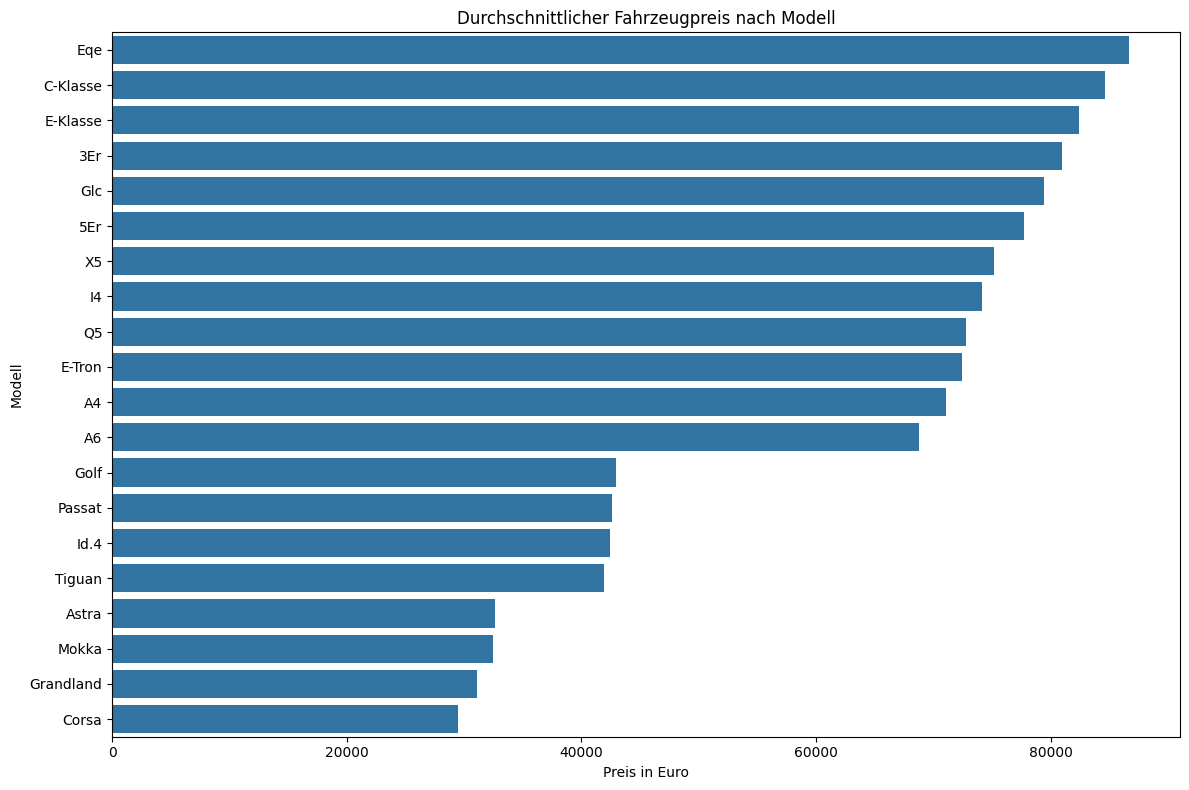

In [18]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=modell_preis.values,
    y=modell_preis.index
)

plt.title("Durchschnittlicher Fahrzeugpreis nach Modell")
plt.xlabel("Preis in Euro")
plt.ylabel("Modell")

plt.tight_layout()
plt.show()

## Einfluss des Fahrzeugmodells auf den Fahrzeugpreis

Die Analyse zeigt deutliche Preisunterschiede zwischen den einzelnen Fahrzeugmodellen.

Die höchsten Durchschnittspreise weisen die Modelle EQE, C-Klasse, E-Klasse und BMW 3er auf.

Modelle wie Golf, Passat, Astra, Mokka oder Corsa liegen dagegen deutlich niedriger.

Die Ergebnisse zeigen, dass das Fahrzeugmodell einen besonders starken Einfluss auf den Fahrzeugpreis besitzt.

Für Machine-Learning-Modelle stellt das Fahrzeugmodell daher einen wichtigen Prädiktor für die Preisvorhersage dar.

In [19]:
kraftstoff_preis = (
    df.groupby("Kraftstoff")["Preis_Euro"]
    .mean()
    .sort_values(ascending=False)
)

kraftstoff_preis

Kraftstoff
Elektro    62363.666667
Hybrid     61999.920000
Diesel     60041.738956
Benzin     55646.662551
Name: Preis_Euro, dtype: float64

Elektrofahrzeuge weisen den höchsten durchschnittlichen Fahrzeugpreis auf.
Hybrid- und Dieselfahrzeuge liegen auf einem ähnlichen Preisniveau.
Benzinfahrzeuge besitzen den niedrigsten Durchschnittspreis.

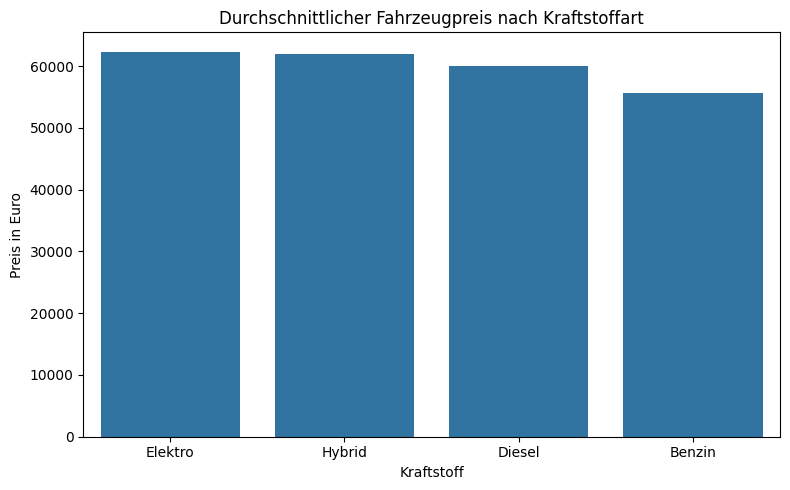

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=kraftstoff_preis.index,
    y=kraftstoff_preis.values
)

plt.title("Durchschnittlicher Fahrzeugpreis nach Kraftstoffart")
plt.xlabel("Kraftstoff")
plt.ylabel("Preis in Euro")

plt.tight_layout()
plt.show()

## Einfluss der Kraftstoffart auf den Fahrzeugpreis

Die Analyse zeigt Unterschiede zwischen den verschiedenen Kraftstoffarten.

Elektrofahrzeuge besitzen den höchsten durchschnittlichen Fahrzeugpreis, gefolgt von Hybrid- und Dieselfahrzeugen.

Benzinfahrzeuge weisen den niedrigsten Durchschnittspreis auf.

Die Ergebnisse deuten darauf hin, dass die Antriebsart einen relevanten Einfluss auf den Fahrzeugpreis besitzt und daher bei der Preisvorhersage berücksichtigt werden sollte.

In [21]:
gruppen = [
    gruppe["Preis_Euro"].values
    for _, gruppe in df.groupby("Kraftstoff")
]

f_statistik, p_wert = stats.f_oneway(*gruppen)

print("F-Statistik:", f_statistik)
print("p-Wert:", p_wert)

F-Statistik: 3.96860537801122
p-Wert: 0.007908118400138482


## ANOVA-Test der Kraftstoffarten

Zur Untersuchung der Preisunterschiede zwischen den Kraftstoffarten wurde ein einfaktorieller ANOVA-Test durchgeführt.

Der Test ergab einen p-Wert von kleiner als 0,05.

Damit kann die Nullhypothese verworfen werden.

Es besteht ein statistisch signifikanter Unterschied zwischen den durchschnittlichen Fahrzeugpreisen der verschiedenen Kraftstoffarten.

Die Kraftstoffart stellt somit einen relevanten Einflussfaktor für den Fahrzeugpreis dar.

# Fazit

Im Rahmen der Einflussanalyse wurden verschiedene potenzielle Einflussfaktoren auf den Fahrzeugpreis untersucht.

Die Ergebnisse zeigen, dass insbesondere die Fahrzeugmarke und das Fahrzeugmodell einen starken Einfluss auf die Preisgestaltung besitzen.

Darüber hinaus konnten Unterschiede zwischen den Kraftstoffarten festgestellt werden. Der durchgeführte ANOVA-Test zeigte statistisch signifikante Preisunterschiede zwischen den einzelnen Kraftstoffgruppen.

Die Analyse verdeutlicht, dass kategorische Merkmale einen wesentlich stärkeren Einfluss auf den Fahrzeugpreis besitzen als die zuvor untersuchten numerischen Variablen.

Die gewonnenen Erkenntnisse liefern wichtige Informationen für die Entwicklung und Interpretation der Machine-Learning-Modelle zur Fahrzeugpreisvorhersage.